# Variational Quantum Classifier（VQC）

## 经典机器学习基线 + Qiskit 量子分类器

本 notebook 使用 Iris 数据集中的两个类别：

- `0 = setosa`
- `1 = versicolor`

并只保留两个特征：花瓣长度（petal length）和花瓣宽度（petal width）。这使每个样本可以编码到一个 **2 量子比特**电路中。

完整流程为：

$$
\text{原始数据}
\longrightarrow
\text{训练集/测试集划分}
\longrightarrow
\text{特征缩放}
\longrightarrow
\begin{cases}
\text{Logistic Regression / SVC},\\
\text{Qiskit VQC}
\end{cases}
\longrightarrow
\text{测试与比较}.
$$


In [2]:
%matplotlib inline

import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display
from scipy.optimize import minimize
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)

try:
    import qiskit
    import qiskit_machine_learning
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.primitives import StatevectorSampler
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_machine_learning.optimizers import SLSQP
    from qiskit_machine_learning.utils import algorithm_globals

    QISKIT_AVAILABLE = True
    algorithm_globals.random_seed = SEED
except ImportError as exc:
    QISKIT_AVAILABLE = False
    QISKIT_IMPORT_ERROR = exc

print(f"Python:                 {sys.version.split()[0]}")
print(f"NumPy:                  {np.__version__}")
print(f"SciPy:                  {scipy.__version__}")
print(f"scikit-learn:           {sklearn.__version__}")

if QISKIT_AVAILABLE:
    print(f"Qiskit:                 {qiskit.__version__}")
    print(f"Qiskit Machine Learning:{qiskit_machine_learning.__version__}")
    print("Execution backend:      Official Qiskit VQC")
else:
    print("Qiskit:                 not installed in this kernel")
    print("Execution backend:      NumPy statevector reference VQC")
    print(f"Import message:          {QISKIT_IMPORT_ERROR}")

Python:                 3.13.5
NumPy:                  2.3.5
SciPy:                  1.17.0
scikit-learn:           1.8.0
Qiskit:                 not installed in this kernel
Execution backend:      NumPy statevector reference VQC
Import message:          No module named 'qiskit'


## 3. VQC 的数学结构

对于输入样本 \(x=(x_1,x_2)\)，本例使用量子特征映射

$$
|\phi(x)\rangle = U_{\phi}(x)|00\rangle,
$$

再施加含有可训练参数 \(\theta\) 的 ansatz：

$$
|\psi(x,\theta)\rangle
=U_{\theta}U_{\phi}(x)|00\rangle.
$$

测量得到四个 bitstring 的概率，然后使用 VQC 的二分类奇偶校验规则：

$$
P(y=0)=P(00)+P(11),
\qquad
P(y=1)=P(01)+P(10).
$$

训练时，经典优化器最小化交叉熵：

$$
L(\theta)
=-\frac{1}{n}\sum_{i=1}^{n}
\log P_{\theta}(y_i\mid x_i).
$$

## 4. 读取并整理 Iris 数据

In [3]:
iris = load_iris()

# 只保留 setosa 与 versicolor，并选择 petal length / petal width 两个特征。
mask = iris.target < 2
X_raw = iris.data[mask][:, [2, 3]].astype(float)
y = iris.target[mask].astype(int)

feature_names = ["petal length (cm)", "petal width (cm)"]
class_names = np.array(["setosa", "versicolor"])

data = pd.DataFrame(X_raw, columns=feature_names)
data["class_id"] = y
data["class_name"] = class_names[y]

print(f"Number of samples: {len(data)}")
print(f"Class counts: {data['class_name'].value_counts().to_dict()}")
display(data.head(10))

Number of samples: 100
Class counts: {'setosa': 50, 'versicolor': 50}


,petal length (cm),petal width (cm),class_id,class_name
0,1.4,0.2,0,setosa
1,1.4,0.2,0,setosa
2,1.3,0.2,0,setosa
3,1.5,0.2,0,setosa
4,1.4,0.2,0,setosa
5,1.7,0.4,0,setosa
6,1.4,0.3,0,setosa
7,1.5,0.2,0,setosa
8,1.4,0.2,0,setosa
9,1.5,0.1,0,setosa


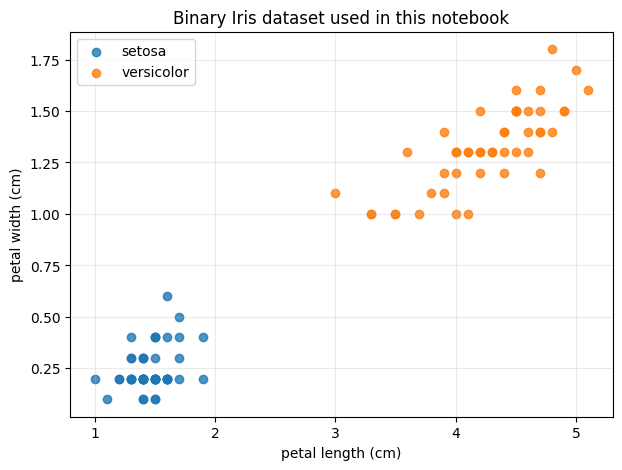

In [4]:
plt.figure(figsize=(7, 5))
for class_id, class_name in enumerate(class_names):
    class_rows = data[data["class_id"] == class_id]
    plt.scatter(
        class_rows[feature_names[0]],
        class_rows[feature_names[1]],
        label=class_name,
        alpha=0.8,
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Binary Iris dataset used in this notebook")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. 划分数据并缩放到量子旋转角范围

训练集与测试集按照类别分层抽样。`MinMaxScaler` 将训练数据映射到 \([0,\pi]\)，从而可直接用作 \(R_y\) 旋转角。测试数据必须使用**同一个训练集 scaler** 进行转换。

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.25,
    stratify=y,
    random_state=SEED,
)

scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training shape: {X_train.shape}")
print(f"Test shape:     {X_test.shape}")
print(f"Scaled training minimum: {X_train.min(axis=0)}")
print(f"Scaled training maximum: {X_train.max(axis=0)}")

Training shape: (75, 2)
Test shape:     (25, 2)
Scaled training minimum: [0. 0.]
Scaled training maximum: [3.14159265 3.14159265]


## 6. 训练经典机器学习基线

In [6]:
logistic_model = LogisticRegression(max_iter=1000, random_state=SEED)
svc_model = SVC(kernel="rbf", probability=True, random_state=SEED)

classical_start = time.perf_counter()
logistic_model.fit(X_train, y_train)
logistic_time = time.perf_counter() - classical_start

classical_start = time.perf_counter()
svc_model.fit(X_train, y_train)
svc_time = time.perf_counter() - classical_start


def metric_row(model_name, train_true, train_pred, test_true, test_pred, train_time):
    precision, recall, f1, _ = precision_recall_fscore_support(
        test_true,
        test_pred,
        average="binary",
        zero_division=0,
    )
    return {
        "Model": model_name,
        "Train accuracy": accuracy_score(train_true, train_pred),
        "Test accuracy": accuracy_score(test_true, test_pred),
        "Test precision": precision,
        "Test recall": recall,
        "Test F1": f1,
        "Training time (s)": train_time,
    }

classical_rows = [
    metric_row(
        "Logistic Regression",
        y_train,
        logistic_model.predict(X_train),
        y_test,
        logistic_model.predict(X_test),
        logistic_time,
    ),
    metric_row(
        "RBF-SVC",
        y_train,
        svc_model.predict(X_train),
        y_test,
        svc_model.predict(X_test),
        svc_time,
    ),
]

display(pd.DataFrame(classical_rows).round(4))

,Model,Train accuracy,Test accuracy,Test precision,Test recall,Test F1,Training time (s)
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,0.0023
1,RBF-SVC,1.0,1.0,1.0,1.0,1.0,0.0009


## 7. 构造量子特征映射与变分 ansatz

为了让 Qiskit 分支与参考 statevector 分支完全对应，本例显式构造电路，而不是调用默认电路。

### Feature map

重复两次：

$$
R_y(x_1)\otimes R_y(x_2)
\quad\text{followed by}\quad CZ.
$$

### Ansatz

$$
R_y(\theta_1)\otimes R_y(\theta_2)
\longrightarrow CX_{0\to1}
\longrightarrow
R_y(\theta_3)\otimes R_y(\theta_4).
$$

因此模型只包含 4 个可训练参数。

In [7]:
NUM_QUBITS = 2
FEATURE_REPS = 2
NUM_WEIGHTS = 4

if QISKIT_AVAILABLE:
    input_parameters = ParameterVector("x", NUM_QUBITS)
    feature_map = QuantumCircuit(NUM_QUBITS, name="FeatureMap")
    for _ in range(FEATURE_REPS):
        feature_map.ry(input_parameters[0], 0)
        feature_map.ry(input_parameters[1], 1)
        feature_map.cz(0, 1)

    weight_parameters = ParameterVector("theta", NUM_WEIGHTS)
    ansatz = QuantumCircuit(NUM_QUBITS, name="Ansatz")
    ansatz.ry(weight_parameters[0], 0)
    ansatz.ry(weight_parameters[1], 1)
    ansatz.cx(0, 1)
    ansatz.ry(weight_parameters[2], 0)
    ansatz.ry(weight_parameters[3], 1)

    print("Feature map:")
    print(feature_map.draw(output="text"))
    print("Ansatz:")
    print(ansatz.draw(output="text"))
else:
    print("Feature map (conceptual circuit):")
    print("|0> --Ry(x[0])--o--Ry(x[0])--o--")
    print("                |             |")
    print("|0> --Ry(x[1])--o--Ry(x[1])--o--")
    print()
    print("Ansatz (conceptual circuit):")
    print("|q0> --Ry(theta[0])--■--Ry(theta[2])--")
    print("                     |")
    print("|q1> --Ry(theta[1])--X--Ry(theta[3])--")

Feature map (conceptual circuit):
|0> --Ry(x[0])--o--Ry(x[0])--o--
                |             |
|0> --Ry(x[1])--o--Ry(x[1])--o--

Ansatz (conceptual circuit):
|q0> --Ry(theta[0])--■--Ry(theta[2])--
                     |
|q1> --Ry(theta[1])--X--Ry(theta[3])--


## 8. NumPy statevector 参考实现

这一部分只在当前 kernel 缺少 Qiskit 时负责执行。它不是经典神经网络：它明确计算 2 量子比特 statevector、量子门演化、Born 概率和 parity 分类概率。安装 Qiskit 后，后续训练单元格会自动跳过这一参考模型并调用官方 `VQC`。

In [8]:
I2 = np.eye(2, dtype=complex)
CZ = np.diag([1.0, 1.0, 1.0, -1.0]).astype(complex)
CNOT_0_TO_1 = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, 1.0, 0.0],
    ],
    dtype=complex,
)


def ry_matrix(angle):
    """Return the one-qubit Ry rotation matrix."""
    cosine = np.cos(angle / 2.0)
    sine = np.sin(angle / 2.0)
    return np.array(
        [[cosine, -sine], [sine, cosine]],
        dtype=complex,
    )


class NumPyReferenceVQC:
    """A deterministic 2-qubit statevector VQC matching this notebook's circuit."""

    def __init__(self, feature_reps=2, maxiter=200, random_state=42):
        self.feature_reps = int(feature_reps)
        self.maxiter = int(maxiter)
        self.random_state = int(random_state)
        self.weights = None
        self.objective_values_ = []
        self.fit_result_ = None

    def _single_probability_vector(self, x, weights):
        state = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)

        # U_phi(x): repeated angle embedding plus CZ entanglement.
        for _ in range(self.feature_reps):
            local_encoding = np.kron(ry_matrix(x[0]), ry_matrix(x[1]))
            state = local_encoding @ state
            state = CZ @ state

        # U_theta: trainable local rotations, CNOT, then local rotations.
        first_layer = np.kron(ry_matrix(weights[0]), ry_matrix(weights[1]))
        second_layer = np.kron(ry_matrix(weights[2]), ry_matrix(weights[3]))
        state = first_layer @ state
        state = CNOT_0_TO_1 @ state
        state = second_layer @ state

        basis_probabilities = np.abs(state) ** 2

        # Binary VQC parity mapping:
        # class 0 <- |00>, |11>; class 1 <- |01>, |10>.
        p_class_0 = basis_probabilities[0] + basis_probabilities[3]
        p_class_1 = basis_probabilities[1] + basis_probabilities[2]
        probabilities = np.array([p_class_0, p_class_1], dtype=float)
        return probabilities / probabilities.sum()

    def predict_proba(self, X):
        if self.weights is None:
            raise RuntimeError("The VQC must be fitted before prediction.")
        X = np.asarray(X, dtype=float)
        return np.vstack(
            [self._single_probability_vector(row, self.weights) for row in X]
        )

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

    def fit(self, X, y, initial_point=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        if initial_point is None:
            rng = np.random.default_rng(self.random_state)
            initial_point = 0.1 * rng.standard_normal(NUM_WEIGHTS)

        self.objective_values_ = []

        def cross_entropy(weights):
            probabilities = np.vstack(
                [self._single_probability_vector(row, weights) for row in X]
            )
            selected = probabilities[np.arange(len(y)), y]
            loss = -np.mean(np.log(np.clip(selected, 1e-12, 1.0)))
            self.objective_values_.append(float(loss))
            return float(loss)

        self.fit_result_ = minimize(
            cross_entropy,
            np.asarray(initial_point, dtype=float),
            method="SLSQP",
            options={
                "maxiter": self.maxiter,
                "ftol": 1e-9,
                "disp": False,
            },
        )
        self.weights = np.asarray(self.fit_result_.x, dtype=float)
        return self


print("NumPyReferenceVQC is ready.")

NumPyReferenceVQC is ready.


## 9. 训练 Variational Quantum Classifier

In [9]:
initial_rng = np.random.default_rng(SEED)
initial_point = 0.1 * initial_rng.standard_normal(NUM_WEIGHTS)
objective_values = []

training_start = time.perf_counter()

if QISKIT_AVAILABLE:
    sampler = StatevectorSampler(default_shots=4096, seed=SEED)
    optimizer = SLSQP(maxiter=200, ftol=1e-9)

    def qiskit_callback(weights, objective_value):
        objective_values.append(float(objective_value))

    quantum_classifier = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        loss="cross_entropy",
        optimizer=optimizer,
        initial_point=initial_point,
        callback=qiskit_callback,
        sampler=sampler,
    )
    quantum_classifier.fit(X_train, y_train)

    execution_model_name = "Qiskit VQC + StatevectorSampler"
    quantum_weights = np.asarray(quantum_classifier.weights, dtype=float)

    def quantum_predict(X):
        return np.asarray(quantum_classifier.predict(X), dtype=int).reshape(-1)

    def quantum_predict_proba(X):
        probabilities = np.asarray(
            quantum_classifier.neural_network.forward(
                input_data=np.asarray(X, dtype=float),
                weights=quantum_classifier.weights,
            ),
            dtype=float,
        )
        probabilities = probabilities.reshape(len(X), -1)
        return probabilities / probabilities.sum(axis=1, keepdims=True)

    optimizer_message = str(quantum_classifier.fit_result)
else:
    quantum_classifier = NumPyReferenceVQC(
        feature_reps=FEATURE_REPS,
        maxiter=200,
        random_state=SEED,
    )
    quantum_classifier.fit(X_train, y_train, initial_point=initial_point)
    objective_values = quantum_classifier.objective_values_

    execution_model_name = "NumPy statevector reference VQC"
    quantum_weights = quantum_classifier.weights
    quantum_predict = quantum_classifier.predict
    quantum_predict_proba = quantum_classifier.predict_proba
    optimizer_message = quantum_classifier.fit_result_.message

quantum_training_time = time.perf_counter() - training_start

print(f"Model used:          {execution_model_name}")
print(f"Training time:       {quantum_training_time:.4f} seconds")
print(f"Objective evaluations: {len(objective_values)}")
print(f"Initial loss:        {objective_values[0]:.6f}")
print(f"Final loss:          {objective_values[-1]:.6f}")
print(f"Learned weights:     {np.round(quantum_weights, 6)}")
print(f"Optimizer status:    {optimizer_message}")

Model used:          NumPy statevector reference VQC
Training time:       0.4682 seconds
Objective evaluations: 91
Initial loss:        1.476916
Final loss:          0.264197
Learned weights:     [ 0.659139 -0.849783  2.64212   1.697812]
Optimizer status:    Optimization terminated successfully


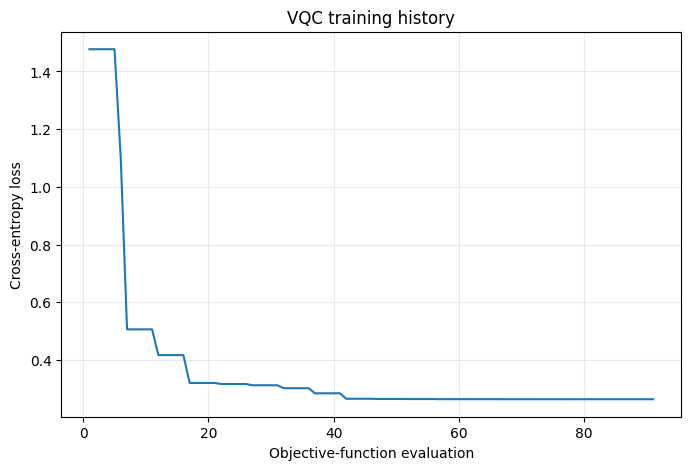

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(objective_values) + 1), objective_values)
plt.xlabel("Objective-function evaluation")
plt.ylabel("Cross-entropy loss")
plt.title("VQC training history")
plt.grid(alpha=0.25)
plt.show()

## 10. 比较经典模型与量子模型

In [11]:
logistic_train_pred = logistic_model.predict(X_train)
logistic_test_pred = logistic_model.predict(X_test)
svc_train_pred = svc_model.predict(X_train)
svc_test_pred = svc_model.predict(X_test)
quantum_train_pred = quantum_predict(X_train)
quantum_test_pred = quantum_predict(X_test)

comparison_rows = [
    metric_row(
        "Logistic Regression",
        y_train,
        logistic_train_pred,
        y_test,
        logistic_test_pred,
        logistic_time,
    ),
    metric_row(
        "RBF-SVC",
        y_train,
        svc_train_pred,
        y_test,
        svc_test_pred,
        svc_time,
    ),
    metric_row(
        execution_model_name,
        y_train,
        quantum_train_pred,
        y_test,
        quantum_test_pred,
        quantum_training_time,
    ),
]

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))

,Model,Train accuracy,Test accuracy,Test precision,Test recall,Test F1,Training time (s)
0,Logistic Regression,1.0000,1.00,1.0000,1.0,1.00,0.0023
1,RBF-SVC,1.0000,1.00,1.0000,1.0,1.00,0.0009
2,NumPy statevector reference VQC,0.9867,0.96,0.9231,1.0,0.96,0.4682


In [12]:
print("VQC classification report on the held-out test set:")
print()
print(
    classification_report(
        y_test,
        quantum_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix array:")
print(confusion_matrix(y_test, quantum_test_pred))

VQC classification report on the held-out test set:

              precision    recall  f1-score   support

      setosa     1.0000    0.9231    0.9600        13
  versicolor     0.9231    1.0000    0.9600        12

    accuracy                         0.9600        25
   macro avg     0.9615    0.9615    0.9600        25
weighted avg     0.9631    0.9600    0.9600        25

Confusion matrix array:
[[12  1]
 [ 0 12]]


<Figure size 600x500 with 0 Axes>

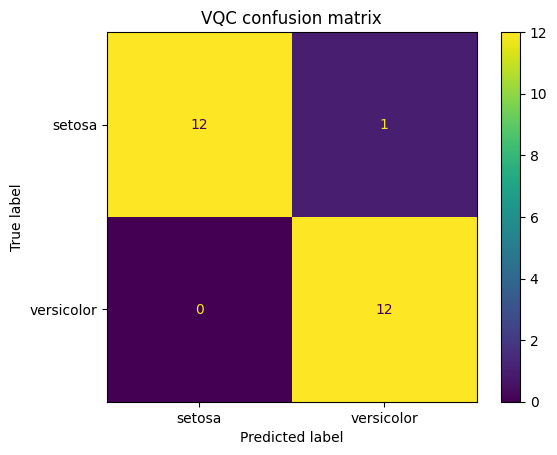

In [13]:
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    quantum_test_pred,
    display_labels=class_names,
    values_format="d",
)
plt.title("VQC confusion matrix")
plt.grid(False)
plt.show()

## 11. 查看测试集中每个样本的预测

In [14]:
quantum_test_probabilities = quantum_predict_proba(X_test)

held_out_results = pd.DataFrame(
    {
        feature_names[0]: X_test_raw[:, 0],
        feature_names[1]: X_test_raw[:, 1],
        "Actual class": class_names[y_test],
        "Logistic prediction": class_names[logistic_test_pred],
        "SVC prediction": class_names[svc_test_pred],
        "VQC prediction": class_names[quantum_test_pred],
        "VQC P(setosa)": quantum_test_probabilities[:, 0],
        "VQC P(versicolor)": quantum_test_probabilities[:, 1],
    }
)

display(held_out_results.round(4))

,petal length (cm),petal width (cm),Actual class,Logistic prediction,SVC prediction,VQC prediction,VQC P(setosa),VQC P(versicolor)
0,4.5,1.6,versicolor,versicolor,versicolor,versicolor,0.3756,0.6244
1,4.7,1.4,versicolor,versicolor,versicolor,versicolor,0.3515,0.6485
2,4.7,1.6,versicolor,versicolor,versicolor,versicolor,0.3937,0.6063
3,1.2,0.2,setosa,setosa,setosa,setosa,0.5922,0.4078
4,4.0,1.3,versicolor,versicolor,versicolor,versicolor,0.1520,0.8480
5,4.5,1.5,versicolor,versicolor,versicolor,versicolor,0.3443,0.6557
6,1.3,0.3,setosa,setosa,setosa,setosa,0.7585,0.2415
7,4.5,1.5,versicolor,versicolor,versicolor,versicolor,0.3443,0.6557
8,3.9,1.1,versicolor,versicolor,versicolor,versicolor,0.0448,0.9552
9,4.5,1.5,versicolor,versicolor,versicolor,versicolor,0.3443,0.6557


## 12. 手动输入几个新样本进行测试

这些输入仍然使用原始厘米单位。预测前必须调用已经拟合好的 `scaler.transform(...)`，不能再次 `fit` 一个新 scaler。

In [15]:
manual_examples = pd.DataFrame(
    {
        feature_names[0]: [1.4, 1.7, 4.5, 5.0, 3.0],
        feature_names[1]: [0.2, 0.4, 1.5, 1.7, 1.0],
        "Description": [
            "Typical setosa",
            "Large setosa-like sample",
            "Typical versicolor",
            "Large versicolor-like sample",
            "Boundary / ambiguous sample",
        ],
    }
)

manual_scaled = scaler.transform(manual_examples[feature_names].to_numpy())

manual_logistic_pred = logistic_model.predict(manual_scaled)
manual_svc_pred = svc_model.predict(manual_scaled)
manual_vqc_pred = quantum_predict(manual_scaled)
manual_vqc_proba = quantum_predict_proba(manual_scaled)

manual_results = manual_examples.copy()
manual_results["Logistic prediction"] = class_names[manual_logistic_pred]
manual_results["SVC prediction"] = class_names[manual_svc_pred]
manual_results["VQC prediction"] = class_names[manual_vqc_pred]
manual_results["VQC P(setosa)"] = manual_vqc_proba[:, 0]
manual_results["VQC P(versicolor)"] = manual_vqc_proba[:, 1]

display(manual_results.round(4))

,petal length (cm),petal width (cm),Description,Logistic prediction,SVC prediction,VQC prediction,VQC P(setosa),VQC P(versicolor)
0,1.4,0.2,Typical setosa,setosa,setosa,setosa,0.7056,0.2944
1,1.7,0.4,Large setosa-like sample,setosa,setosa,setosa,0.9731,0.0269
2,4.5,1.5,Typical versicolor,versicolor,versicolor,versicolor,0.3443,0.6557
3,5.0,1.7,Large versicolor-like sample,versicolor,versicolor,versicolor,0.4209,0.5791
4,3.0,1.0,Boundary / ambiguous sample,versicolor,versicolor,versicolor,0.0972,0.9028


## 13. 自动检查模型输出

In [16]:
# Test 1: probability matrix has the expected shape.
assert quantum_test_probabilities.shape == (len(X_test), 2)

# Test 2: every probability vector sums to one.
assert np.allclose(quantum_test_probabilities.sum(axis=1), 1.0, atol=1e-6)

# Test 3: all probabilities are valid.
assert np.all((quantum_test_probabilities >= 0.0) & (quantum_test_probabilities <= 1.0))

# Test 4: predictions only use the two known labels.
assert set(np.unique(quantum_test_pred)).issubset({0, 1})

# Test 5: manual-example output has one row per input sample.
assert len(manual_vqc_pred) == len(manual_examples)

# Test 6: the trained model performs substantially better than random guessing.
assert accuracy_score(y_test, quantum_test_pred) >= 0.80

print("All 6 automated checks passed.")

All 6 automated checks passed.


## 14. 结果说明

- Logistic Regression 和 RBF-SVC 是经典基线。
- VQC 的量子部分负责生成依赖于输入和可训练参数的 bitstring 概率分布。
- `SLSQP` 是经典优化器，因此整个训练过程是一个**量子—经典混合循环**。
- 该数据集很小且类别容易分离，所以经典模型通常表现非常好；本例的重点是展示完整且可复用的 VQC 工作流，而不是证明量子优势。
- 使用 Qiskit 的有限 shots sampler 重新运行时，目标函数与预测概率可能因抽样噪声而有轻微变化。

### 官方文档

- [Qiskit Machine Learning VQC API](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html)
- [Training a Quantum Model on a Real Dataset](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02a_training_a_quantum_model_on_a_real_dataset.html)
- [Qiskit StatevectorSampler API](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.primitives.StatevectorSampler)